In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from LogisticRegression import LogisticRegression

In [13]:
X, y = datasets.make_blobs(
    n_samples=200,
    n_features=2,
    centers=2,
    cluster_std=1.5,
    random_state=4
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1234
)

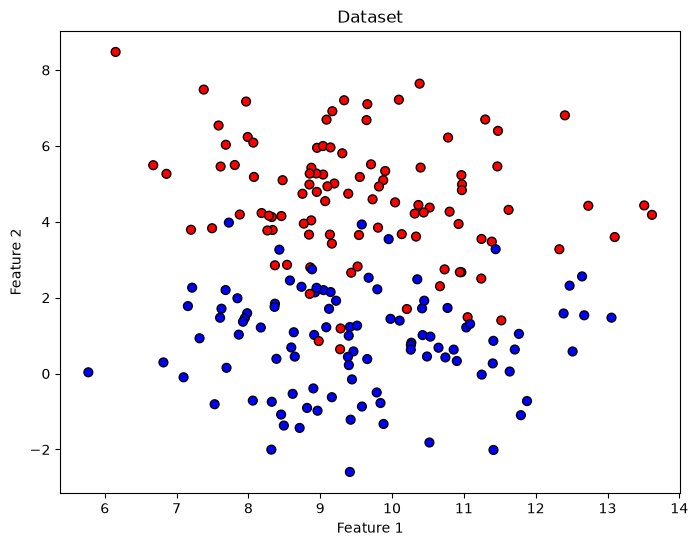

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="bwr",
    marker="o",
    edgecolors="k",
    s=40
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset")
plt.show()

In [15]:
model = LogisticRegression(lr=0.01)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

def accuracy(y_pred, y_test):
    accuracy = np.sum(y_pred == y_test) / len(y_test)
    return accuracy

acc = accuracy(y_pred, y_test)

print("Accuracy:", acc)
print("Weights:", model.w)
print("Bias:", model.b)
print("Final cost:", model.J_history[-1])

Accuracy: 0.925
Weights: [-0.32694417  1.29856111]
Bias: -0.15275868925883573
Final cost: 0.28251384960954845


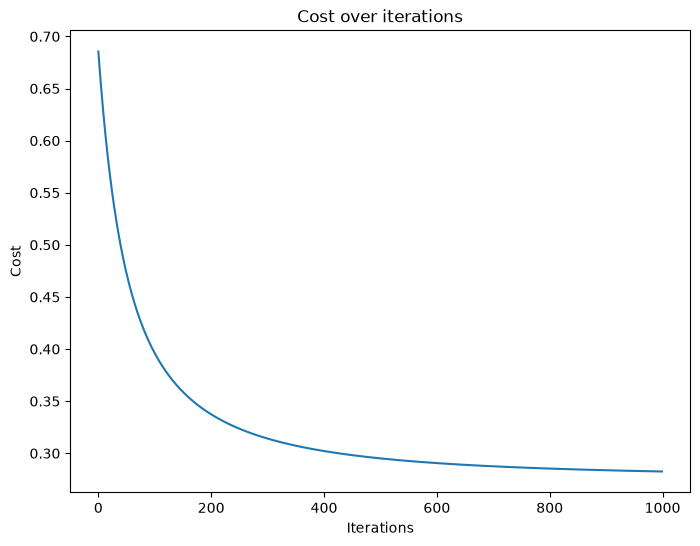

In [16]:
plt.figure(figsize=(8, 6))

plt.plot(model.J_history)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost over iterations")
plt.show()

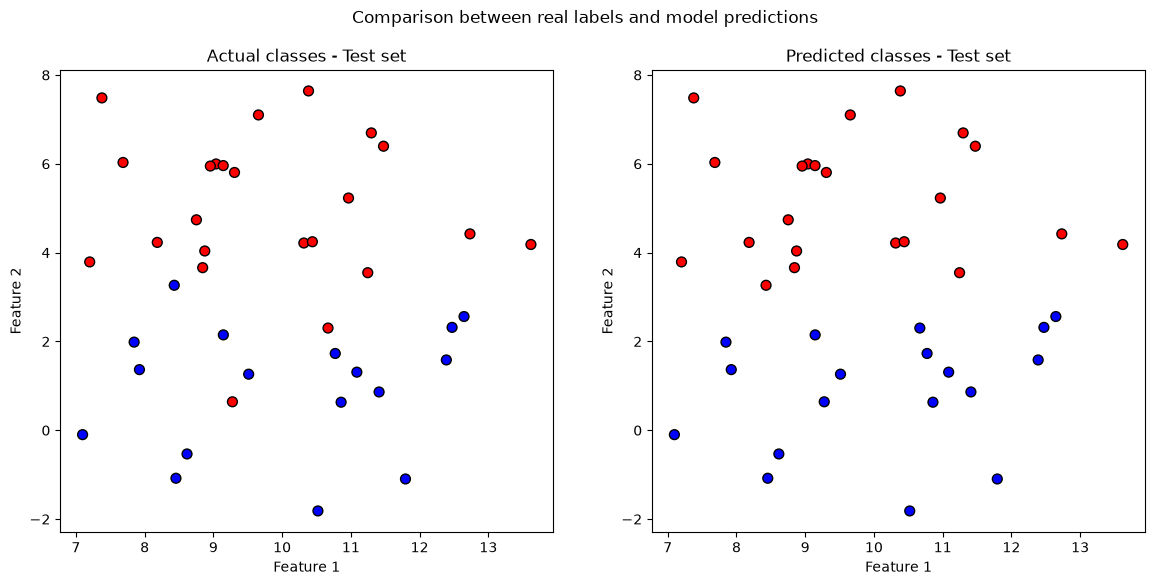

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap="bwr",
    marker="o",
    edgecolors="k",
    s=50
)

axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].set_title("Actual classes - Test set")


axes[1].scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_pred,
    cmap="bwr",
    marker="o",
    edgecolors="k",
    s=50
)

axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].set_title("Predicted classes - Test set")

plt.suptitle("Comparison between real labels and model predictions")
plt.show()

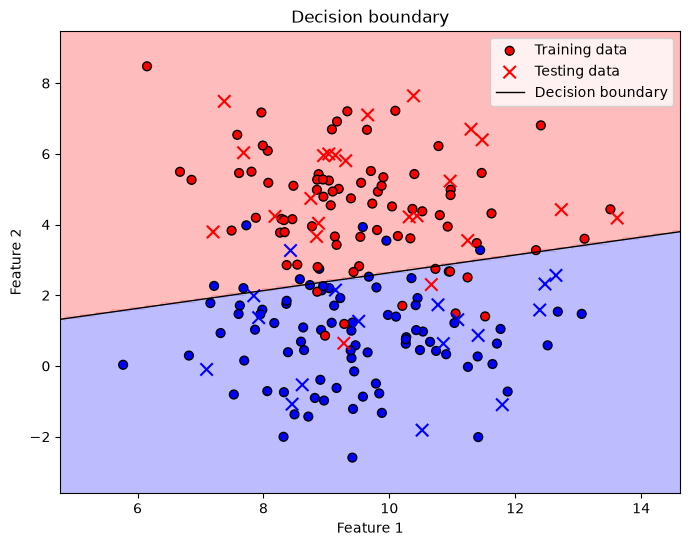

In [18]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

X_grid = np.c_[xx.ravel(), yy.ravel()]

Z = model.predict(X_grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="bwr")

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap="bwr",
    marker="o",
    edgecolors="k",
    s=40,
    label="Training data"
)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap="bwr",
    marker="x",
    s=80,
    label="Testing data"
)

x_values = np.array([x_min, x_max])
y_values = -(model.w[0] * x_values + model.b) / model.w[1]

plt.plot(
    x_values,
    y_values,
    color="black",
    linewidth=1,
    label="Decision boundary"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary")
plt.legend()
plt.show()